In [ ]:
!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu132

Looking in indexes: https://download.pytorch.org/whl/cu132


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
CUDA available: True


## 2. PyTorch vs TensorFlow + the dynamic computation graph

| | **PyTorch** | **TensorFlow / Keras** |
|---|---|---|
| Feel | Pythonic, imperative | Higher-level via Keras |
| Graph | **Dynamic** (define-by-run) | Static by default; eager available |
| Training loop | **You write it** | Hidden in `model.fit()` |
| Debugging | Standard Python | Harder to peek inside |
| Research | **Dominant** | Smaller |
| Deploy | Strong & growing | **Very strong** |

**Analogy:** static graph = write the whole recipe then cook · dynamic graph = cook as you go, tasting at every step.

In [ ]:
# Dynamic graph: ordinary Python control flow just works inside the "model"
def model_fn(x, use_extra_step):
    y = x * 2
    if use_extra_step:        # a real Python 'if' inside the computation
        y = y + 1
    return y

x = torch.tensor(3.0, requires_grad=True)
print("with extra step:   ", model_fn(x, True).item())
print("without extra step:", model_fn(x, False).item())

with extra step:    7.0
without extra step: 6.0


## 3. Tensors & GPU

In [ ]:
# Creating tensors
a = torch.tensor([1.0, 2.0, 3.0])           # 1-D
m = torch.tensor([[1.0, 2.0], [3.0, 4.0]])  # 2-D

zeros  = torch.zeros(2, 3)
ones   = torch.ones(2, 3)
rng    = torch.randn(2, 2)                   # random normal
arange = torch.arange(0, 10, 2)             # tensor([0, 2, 4, 6, 8])

print(m)
print("shape:", m.shape, "| dtype:", m.dtype, "| dim:", m.dim())

tensor([[1., 2.],
        [3., 4.]])
shape: torch.Size([2, 2]) | dtype: torch.float32 | dim: 2


In [ ]:
print(a)
print("shape:", a.shape, "| dtype:", a.dtype, "| dim:", a.dim())

tensor([1., 2., 3.])
shape: torch.Size([3]) | dtype: torch.float32 | dim: 1


In [ ]:
print(zeros)
print("shape:", zeros.shape, "| dtype:", zeros.dtype, "| dim:", zeros.dim())

tensor([[0., 0., 0.],
        [0., 0., 0.]])
shape: torch.Size([2, 3]) | dtype: torch.float32 | dim: 2


In [ ]:
print(arange)
print("shape:", arange.shape, "| dtype:", arange.dtype, "| dim:", arange.dim())

tensor([0, 2, 4, 6, 8])
shape: torch.Size([5]) | dtype: torch.int64 | dim: 1


In [ ]:
# NumPy <-> Torch  (note: from_numpy SHARES memory)
arr  = np.array([[1.0, 2.0], [3.0, 4.0]])
t    = torch.from_numpy(arr)   # NumPy -> Tensor (shares memory!)
back = t.numpy()               # Tensor -> NumPy
print("tensor:\n", t)
print("back to numpy:\n", back)

tensor:
 tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)
back to numpy:
 [[1. 2.]
 [3. 4.]]


### The two multiplications (same trap as Module 1)

In [ ]:
A = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
B = torch.tensor([[0.5, -1.0], [1.0, 2.0]])

print("ELEMENT-WISE A * B:\n", A * B)
print("\nMATRIX MULT  A @ B:\n", A @ B)

x = torch.arange(12)
print("\nreshape with view(3,4):\n", x.view(3, 4))
print("add batch dim -> unsqueeze(0).shape:", x.unsqueeze(0).shape) #np.expand.dims(x,0)

ELEMENT-WISE A * B:
 tensor([[ 0.5000, -2.0000],
        [ 3.0000,  8.0000]])

MATRIX MULT  A @ B:
 tensor([[2.5000, 3.0000],
        [5.5000, 5.0000]])

reshape with view(3,4):
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
add batch dim -> unsqueeze(0).shape: torch.Size([1, 12])


### CPU ↔ GPU — the `.to(device)` pattern


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

x = torch.randn(3, 3).to(device)   # move a tensor to the device
print("tensor is on:", x.device)

Using device: cuda
tensor is on: cuda:0


## 4. Autograd — PyTorch's `GradientTape` sibling

**Analogy:** every op drops a breadcrumb; `.backward()` follows the trail backward from the loss to every parameter (the chain rule).

In [ ]:
x = torch.tensor(3.0, requires_grad=True)
y = x**2 + 2*x - 5      # same example as Module 1's GradientTape, on purpose

y.backward()            # compute dy/dx (this is TF's tape.gradient)
print("dy/dx at x=3:", x.grad.item())   # 2x+2 -> 8.0

dy/dx at x=3: 8.0


### A manual training step

In [ ]:
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
x = torch.tensor(2.0)
y_true = torch.tensor(20.0)
lr = 0.01

for step in range(50):
    y_pred = w * x + b
    loss = (y_pred - y_true) ** 2       # squared error

    loss.backward()                     # fills w.grad and b.grad
    with torch.no_grad():               # don't track the update itself
        w -= lr * w.grad
        b -= lr * b.grad
        w.grad.zero_()                  # MUST reset grads each step
        b.grad.zero_()

print(f"w={w.item():.2f}, b={b.item():.2f}, loss={loss.item():.4f}")

w=8.16, b=3.58, loss=0.0106


## 5. Datasets & DataLoaders

In [ ]:
from torchvision import datasets, transforms

transform = transforms.Compose([transforms.ToTensor()])   # scales images to [0,1]

train_ds = datasets.FashionMNIST(root="data", train=True,  download=True, transform=transform)
test_ds  = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)    # shuffle TRAIN
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)   # never shuffle TEST

images, labels = next(iter(train_loader))
print("Batch images:", images.shape)   # (64, 1, 28, 28) = (batch, channels, H, W)
print("Batch labels:", labels.shape)   # (64,)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.73MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.6MB/s]

Batch images: torch.Size([64, 1, 28, 28])
Batch labels: torch.Size([64])


### Building a CUSTOM Dataset — the pattern you'll reuse forever

In [ ]:
class TabularDataset(Dataset):
    """Wraps NumPy feature/label arrays as a PyTorch Dataset."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)   # long = int labels for classification

    def __len__(self):
        return len(self.X)                # total number of samples

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]   # one (features, label) pair


X = np.random.randn(200, 10).astype("float32")
y = np.random.randint(0, 3, size=200)

ds = TabularDataset(X, y)
loader = DataLoader(ds, batch_size=16, shuffle=True)
xb, yb = next(iter(loader))
print("custom batch:", xb.shape, yb.shape)   # (16, 10) (16,)

custom batch: torch.Size([16, 10]) torch.Size([16])


## 6. Defining a network: `nn.Module`, `forward`, loss, optimizer


**Key difference:** the output layer produces **raw logits** — no softmax. PyTorch's `CrossEntropyLoss` applies softmax internally. Adding your own would apply it twice.

In [ ]:
class MLP(nn.Module):
    """A simple multi-layer perceptron for image classification."""
    def __init__(self, input_size=28*28, hidden=128, num_classes=10):
        super().__init__()                       # ALWAYS call this first
        self.flatten = nn.Flatten()              # (B,1,28,28) -> (B,784)
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden),       # fully-connected layer
            nn.ReLU(),                           # non-linearity
            nn.Linear(hidden, num_classes),      # output logits (no softmax!)
        )

    def forward(self, x):
        return self.net(self.flatten(x))         # returns raw logits

print(MLP())

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [ ]:
layer = nn.Linear(in_features=4, out_features=3)   # 4 inputs -> 3 neurons
x = torch.randn(2, 4)                               # batch of 2, 4 features each
print("output shape:", layer(x).shape)              # (2, 3)
print("weight shape:", layer.weight.shape)          # (3, 4)
print("bias shape:  ", layer.bias.shape)            # (3,)

output shape: torch.Size([2, 3])
weight shape: torch.Size([3, 4])
bias shape:   torch.Size([3])


### Loss & optimizer

| Task | Output | Loss | Label dtype |
|---|---|---|---|
| Multi-class | logits | `nn.CrossEntropyLoss` | `long` |
| Binary | 1 logit | `nn.BCEWithLogitsLoss` | `float` |
| Regression | 1 value | `nn.MSELoss` | `float` |


In [ ]:
criterion = nn.CrossEntropyLoss()                  # multi-class; applies softmax internally
optimizer = optim.Adam(MLP().parameters(), lr=1e-3)  # Adam is the default
print("loss:", criterion)
print("optimizer:", optimizer.__class__.__name__)

loss: CrossEntropyLoss()
optimizer: Adam


## 7. The training loop — the heart of PyTorch

> 1. **Zero** the gradients — `optimizer.zero_grad()`
> 2. **Forward** — `outputs = model(inputs)`
> 3. **Loss** — how wrong are we?
> 4. **Backward** — `loss.backward()` (autograd computes gradients)
> 5. **Step** — `optimizer.step()` (update the weights)
>
> Zero, forward, loss, backward, step. That's the whole religion. This is what `model.fit()` was doing all along.

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()                      # TRAIN mode (enables dropout, etc.)
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)   # data -> device

        # --- the five sacred steps ---
        optimizer.zero_grad()                # 1. zero old gradients
        outputs = model(inputs)              # 2. forward pass
        loss = criterion(outputs, labels)    # 3. compute loss
        loss.backward()                      # 4. backprop (autograd)
        optimizer.step()                     # 5. update weights
        # -----------------------------

        running_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

print("train_one_epoch defined.")

train_one_epoch defined.


### The validation loop

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()                       # EVAL mode: dropout off, batchnorm uses running stats
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():              # no gradient tracking -> faster, less memory
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

print("evaluate defined.")

evaluate defined.


## 8. 🚀 End-to-end project: Fashion-MNIST in PyTorch

We already loaded the data in Section 5. Let's build the model and train.

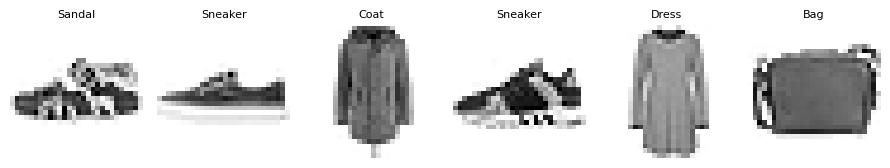

In [ ]:
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Quick look at a batch
images, labels = next(iter(train_loader))
plt.figure(figsize=(9, 3))
for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(images[i].squeeze(), cmap="binary")
    plt.title(class_names[labels[i]], fontsize=8); plt.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28*28, 128), nn.ReLU(),
            nn.Linear(128, 10),                 # logits
        )
    def forward(self, x):
        return self.net(self.flatten(x))

model = FashionMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
print(model)

FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [ ]:
epochs = 10
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(epochs):
    tr_loss, tr_acc  = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)
    for k, v in zip(history, [tr_loss, val_loss, tr_acc, val_acc]):
        history[k].append(v)
    print(f"Epoch {epoch+1:2d}/{epochs} | train acc {tr_acc:.3f} | test acc {val_acc:.3f}")

Epoch  1/10 | train acc 0.810 | test acc 0.831
Epoch  2/10 | train acc 0.857 | test acc 0.854
Epoch  3/10 | train acc 0.869 | test acc 0.862
Epoch  4/10 | train acc 0.879 | test acc 0.857
Epoch  5/10 | train acc 0.886 | test acc 0.875
Epoch  6/10 | train acc 0.890 | test acc 0.876
Epoch  7/10 | train acc 0.896 | test acc 0.876
Epoch  8/10 | train acc 0.899 | test acc 0.879
Epoch  9/10 | train acc 0.904 | test acc 0.881
Epoch 10/10 | train acc 0.907 | test acc 0.885


### Plot the curves

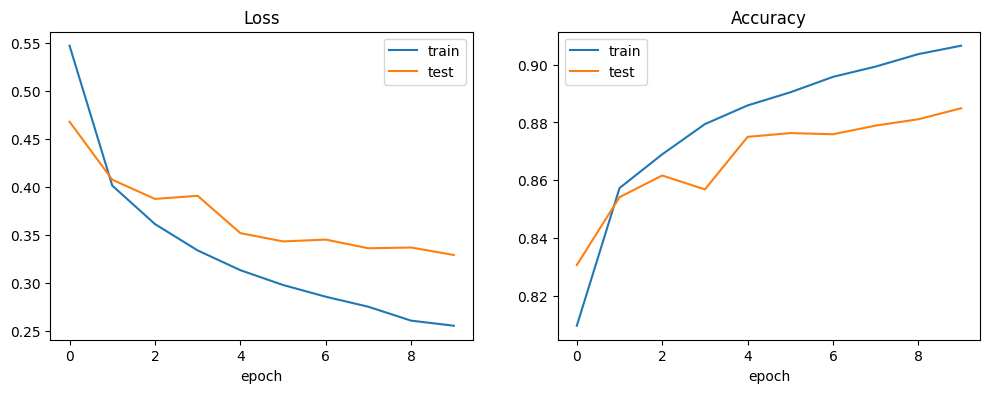

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["train_loss"], label="train"); ax1.plot(history["val_loss"], label="test")
ax1.set_title("Loss"); ax1.set_xlabel("epoch"); ax1.legend()
ax2.plot(history["train_acc"], label="train"); ax2.plot(history["val_acc"], label="test")
ax2.set_title("Accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
plt.show()

### Inference on a single image

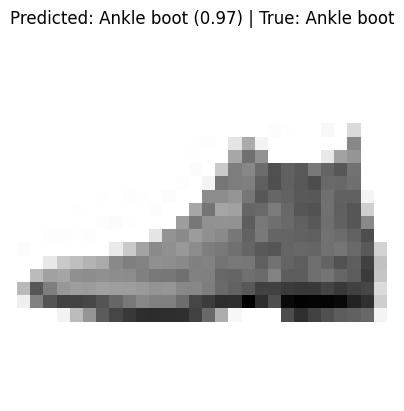

In [ ]:
model.eval()
img, truth = test_ds[0]
with torch.no_grad():
    probs = torch.softmax(model(img.unsqueeze(0).to(device)), dim=1)
guess = probs.argmax(1).item()

plt.imshow(img.squeeze(), cmap="binary")
plt.title(f"Predicted: {class_names[guess]} ({probs.max():.2f}) | True: {class_names[truth]}")
plt.axis("off"); plt.show()

### Save & reload — the `state_dict` way

In [ ]:
# SAVE just the learned parameters
torch.save(model.state_dict(), "fashion_pytorch.pth")

# LOAD: rebuild the SAME architecture, then load weights into it
reloaded = FashionMLP().to(device)
reloaded.load_state_dict(torch.load("fashion_pytorch.pth", map_location=device))
reloaded.eval()

acc = evaluate(reloaded, test_loader, criterion, device)[1]
print(f"Reloaded model test accuracy: {acc:.3f}  (matches the original)")

Reloaded model test accuracy: 0.885  (matches the original)
